In [12]:
pip install EMD-signal

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import PyEMD
print(PyEMD.__version__)

1.6.4


In [14]:
import matplotlib.pyplot as plt
# 导入matplotlib的pyplot模块，用于数据可视化。
import tensorflow as tf
# 导入tensorflow库，用于深度学习模型的构建和训练
from PyEMD import EMD, EEMD, CEEMDAN
# 从pyemd库导入EMD, EEMD, CEEMDAN，用于模态分解
import pandas as pd
# 导入pandas库，用于数据处理和分析
import warnings
# 导入warnings库，用于控制警告消息
warnings.filterwarnings("ignore")

In [15]:
gpus = tf.config.experimental.list_physical_devices(device_type='GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [16]:
# 用来正常显示中文/英文标签（保持与模板一致）
plt.rcParams['font.sans-serif'] = ['Times New Roman']
# 用来正常显示负号
plt.rcParams['axes.unicode_minus'] = False

In [18]:
df_raw_data = pd.read_csv('Japan-DroughtPrediction.csv')

# 确保时间列为Datetime并按时间排序
df_raw_data['Month'] = pd.to_datetime(df_raw_data['Month'])
df_raw_data = df_raw_data.sort_values('Month').reset_index(drop=True)

# 只分解目标 cdd（推荐做法），构造与模板一致的 Series 写法
series_close = pd.Series(
    df_raw_data['cdd'].astype(float).values,
    index=df_raw_data['Month']
)
# 创建一个pandas的Series对象。
# df_raw_data['cdd'].values提取'cdd'列的值作为Series的数据。
# index=df_raw_data['Month']设置Series的索引为时间戳（YYYY-MM）
print(series_close)

Month
1950-01-01    5.10
1950-02-01    5.69
1950-03-01    7.71
1950-04-01    9.37
1950-05-01    8.14
              ... 
2023-08-01    5.29
2023-09-01    4.89
2023-10-01    6.45
2023-11-01    7.78
2023-12-01    7.16
Length: 888, dtype: float64


In [19]:
def ceemdan_decompose(series=None, trials=100):
    # 定义CEEMDAN分解函数。
    # series: 待分解的时间序列数据。
    # trials: CEEMDAN的试验次数，用于生成噪声。

    decom = CEEMDAN()
    # 创建CEEMDAN对象。

    decom.trials = trials
    # 设置CEEMDAN对象的试验次数。

    df_ceemdan = pd.DataFrame(decom(series.values).T)
    # 对时间序列数据执行CEEMDAN分解，并将结果转置后转换为DataFrame。

    df_ceemdan.columns = ['imf' + str(i+1) for i in range(len(df_ceemdan.columns))]
    # 为DataFrame的每一列命名，表示每个内在模态函数（IMF）。

    return df_ceemdan
    # 返回分解结果的DataFrame。

In [20]:
df_ceemdan = ceemdan_decompose(series_close)
# 对series_close进行CEEMDAN分解，并返回结果的DataFrame。

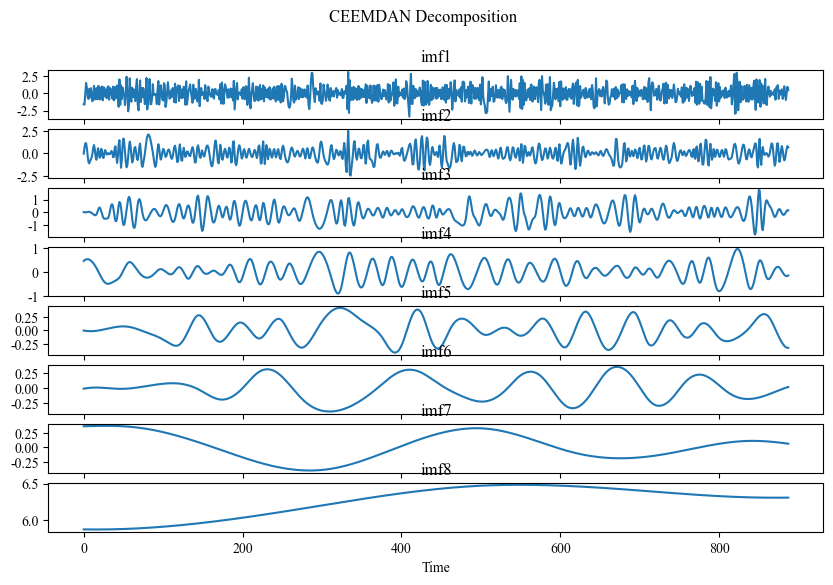

In [21]:
# 可视化VMD分解结果
fig, axs = plt.subplots(nrows=len(df_ceemdan.columns), figsize=(10, 6), sharex=True)
# 创建一个绘图对象和多个子图对象。
for i, col in enumerate(df_ceemdan.columns):
    axs[i].plot(df_ceemdan[col])
    axs[i].set_title(col)
    # 遍历每个模态并绘制在子图上。

plt.suptitle('CEEMDAN Decomposition')
# 设置图表的总标题。

plt.xlabel('Time')
# 设置x轴的标签。

plt.show()
# 显示图表。

In [22]:
print(df_ceemdan)
df_ceemdan.to_excel("CEEMDAN-JAPAN-CDD.xlsx",index=False)
#保存数据为CEEMDAN-CHINA-CDD.xlsx

         imf1      imf2      imf3      imf4      imf5      imf6      imf7  \
0   -1.557925 -0.035285  0.013384  0.449815 -0.001698 -0.011413  0.366311   
1   -1.639604  0.621284  0.000168  0.478119 -0.004248 -0.009088  0.366715   
2   -0.122160  1.107719 -0.005514  0.499756 -0.006510 -0.006911  0.367112   
3    1.485884  1.141537 -0.002192  0.514258 -0.008475 -0.004885  0.367503   
4    0.811370  0.566168  0.009737  0.521745 -0.010138 -0.003012  0.367886   
..        ...       ...       ...       ...       ...       ...       ...   
883  0.072429 -0.604533 -0.099463 -0.155807 -0.303096 -0.000295  0.071564   
884 -0.957561 -0.054035  0.008010 -0.175049 -0.314511  0.004140  0.069712   
885 -0.044455  0.504825  0.107766 -0.181493 -0.322307  0.008437  0.067832   
886  0.927343  0.799939  0.165705 -0.174715 -0.326286  0.012586  0.065925   
887  0.430004  0.664207  0.156572 -0.154401 -0.326568  0.016578  0.063990   

         imf8  
0    5.876812  
1    5.876654  
2    5.876507  
3    5.8763